In [2]:
from sqlalchemy import create_engine
import pandas as pd

engine = create_engine(
    f"mysql+pymysql://{USER}:{PASSWORD}@{HOST}:{PORT}/{DATABASE}"
)

query = """
SELECT *
FROM brand_sales01;
"""

df = pd.read_sql(query, engine)

df

,id,brand_name,sales,channel
0,1,Nike,120000,Instagram
1,2,Adidas,90000,Naver
2,3,Musinsa,150000,Youtube


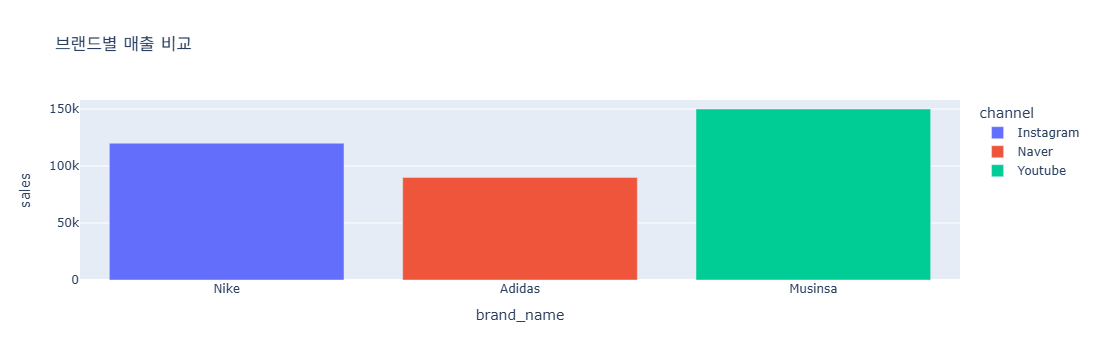

In [4]:
import plotly.express as px

fig = px.bar(
    df,
    x= "brand_name",
    y="sales",
    color="channel",
    title="브랜드별 매출 비교"
)

fig.show()

In [7]:
import os # operating system = 운영체제 => 작업중인 폴더명, 파일목록 등 확인하고자 할 때
import pandas as pd
import plotly.express as px
from sqlalchemy import create_engine
from dotenv import load_dotenv

load_dotenv()

HOST = os.getenv("DB_HOST")
PORT = os.getenv("DB_PORT")
USER = os.getenv("DB_USER")
PASSWORD = os.getenv("DB_PASSWORD")
DATABASE = os.getenv("DB_NAME")

engine = create_engine(
    f"mysql+pymysql://{USER}:{PASSWORD}@{HOST}:{PORT}/{DATABASE}"
)

query = """
SELECT *
FROM brands01;
"""

raw_df = pd.read_sql(query, engine)
raw_df

,brand_id,brand_name
0,2,Adidas
1,3,Musinsa
2,1,Nike


In [8]:
raw_df.to_csv("backup_brands01.csv", index=False, encoding="utf-8-sig")

In [9]:
summary_df = raw_df.groupby("brand_name").size().reset_index(name="brand_count")

summary_df

,brand_name,brand_count
0,Adidas,1
1,Musinsa,1
2,Nike,1


In [10]:
summary_df.to_sql(
    name="brand_summary01",
    con=engine,
    if_exists="replace",
    index=False
)

3

In [11]:
import subprocess

def run_git_command(command) :
    result = subprocess.run(
        command,
        shell=True,
        capture_output=True,
        text=True
    )

    print(result.stdout)

    if result.stderr :
        print(result.stderr)

run_git_command("git status")
run_git_command("git add backup_brands01.csv")
run_git_command("git commit -m 'Feat: Add MySQL data backup'")
run_git_command("git push origin master")

On branch master

No commits yet

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.env
	.gitignore
	.ipynb_checkpoints/
	backup_brands01.csv
	railway_mysql.ipynb

nothing added to commit but untracked files present (use "git add" to track)



error: pathspec 'Add' did not match any file(s) known to git
error: pathspec 'MySQL' did not match any file(s) known to git
error: pathspec 'data' did not match any file(s) known to git
error: pathspec 'backup'' did not match any file(s) known to git


error: src refspec master does not match any
error: failed to push some refs to 'https://github.com/jiwoooong03-lab/railway_260515.git'

